<h1 style="color:green;font-size:22px;">Function 4 - Black-Box Optimisation</h1>
<h1 style="color:#0000CD;font-size:19px;">Objective and reading guide</h1>

Function 4 is a four-dimensional black-box objective over the bounded domain $[0,1]^4$. Its analytical form and physical interpretation are unknown. The objective is to **find the input configuration that maximises the observed value of Function 4** under a limited sequential-evaluation budget.

As an analogy, the inputs may be viewed as tunable parameters in an expensive operational model: each evaluation returns one performance score, while the underlying response surface remains hidden. Bayesian optimisation uses the observations collected so far to decide where to query next. This analogy is illustrative only; the analysis relies solely on observed input-output pairs.

The 13 historical queries are organised by strategy phase:

1. **Global RBF-UCB exploration** (Weeks 1–5)
2. **Global RBF-EI improvement search** (Weeks 6–12)
3. **Local Matérn-5/2 EI refinement** (Week 13)

The notebook keeps the settings that affected the historical decisions, but the emphasis is on why the search changed, what the returned observations implied, and whether the main decisions are robust to reasonable modelling and search choices.

In [1]:
# Standard libraries
import sys
import warnings
from pathlib import Path

# Numerical computing, data handling and visualisation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scipy
from scipy.stats import norm, qmc

# Scikit-learn
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

# BBO project root
ROOT_DIR = Path.cwd().parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

# BBO project package
from src.config import RANDOM_SEED
from src.data import load_initial_data, extract, update_data, historical_record
from src.search import search_region, filter_candidates, exhaustive_cartesian_search_4d, _original_grid_blocks_4d
from src.acquisition import upper_confidence_bound, expected_improvement
from src.surrogate import build_kernel
from src.plotting import plot_pairwise_observations_2d, plot_sequential_query_performance
from src.validation import sequential_performance, kernel_choice_validation, exhaustive_kappa_sensitivity_4d

# Notebook configuration
FUNCTION_ID = 4
DIMENSION = 4
INITIAL_OBSERVATIONS = 30

warnings.filterwarnings("ignore", category=ConvergenceWarning)

<h1 style="color:#0000CD;font-size:19px;">1. Initial observations</h1>

**1.1 - Extraction of initial data**

The experiment begins with **30 observations** in four dimensions. Before fitting a surrogate, the first task is to identify the initial incumbent and inspect how sparsely the observations cover the domain.

The **incumbent** is the best objective value observed so far. It is the benchmark that every later query attempts to improve.

In [2]:
data = load_initial_data(FUNCTION_ID)
inputs, outputs = extract(data)

initial_inputs = inputs.copy()
initial_outputs = outputs.copy()
initial_best_idx = int(np.argmax(initial_outputs))

print(f"Initial observations: {len(initial_outputs)}")
print(f"Initial best: {initial_outputs[initial_best_idx]:.6f}")
print(f"Initial best location: {initial_inputs[initial_best_idx]}")

display(data)

Initial observations: 30
Initial best: -4.025542
Initial best location: [0.57776561 0.42877174 0.42582587 0.24900741]


,x1,x2,x3,x4,y
0,0.896981,0.725628,0.175404,0.701694,-22.108288
1,0.889356,0.499588,0.539269,0.508783,-14.601397
2,0.250946,0.033693,0.145380,0.494932,-11.699932
3,0.346962,0.006250,0.760564,0.613024,-16.053765
4,0.124871,0.129770,0.384400,0.287076,-10.069633
5,0.801303,0.500231,0.706645,0.195103,-15.487083
6,0.247708,0.060445,0.042186,0.441324,-12.681685
7,0.746702,0.757092,0.369353,0.206566,-16.026400
8,0.400665,0.072574,0.886768,0.243842,-17.049235
9,0.626071,0.586751,0.438806,0.778858,-12.741766


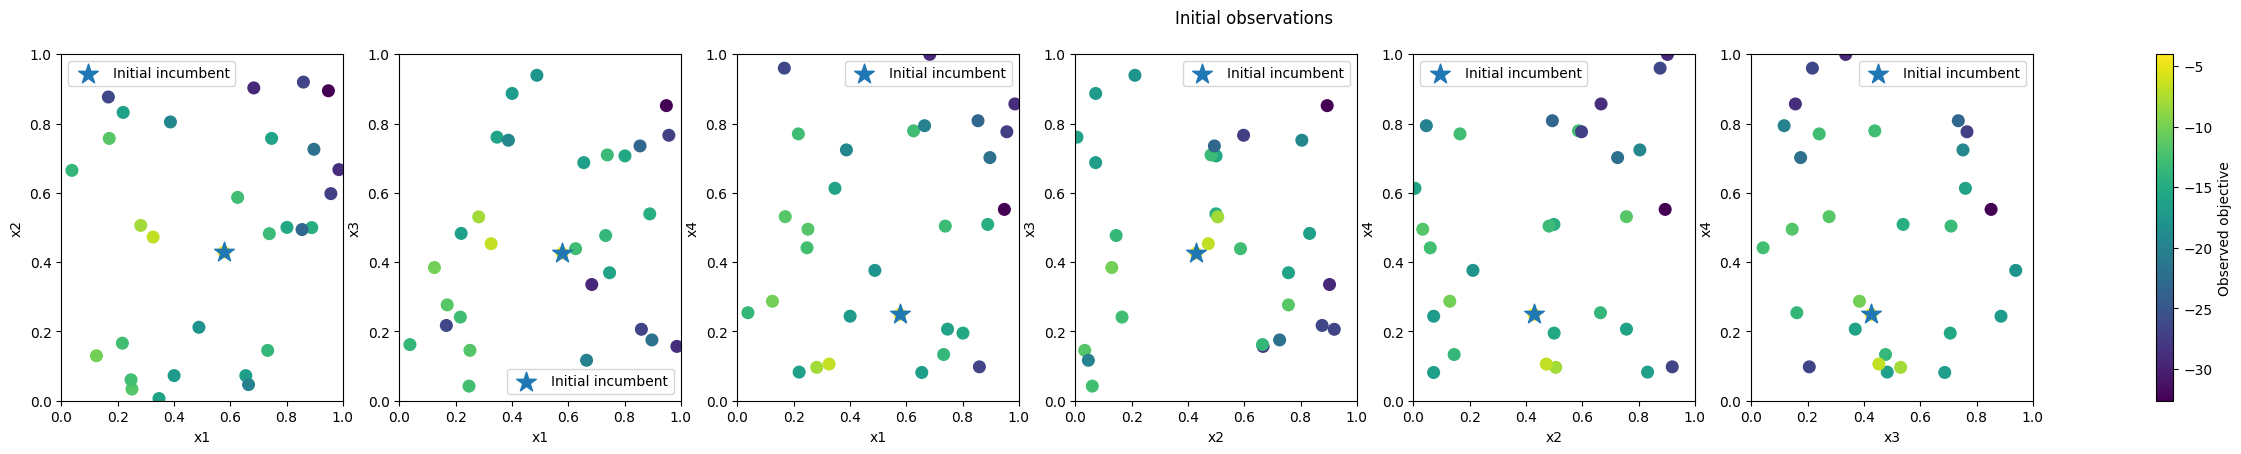

In [3]:
plot_pairwise_observations_2d(inputs, outputs)

**Observations:**

- The 30 initial observations remain sparse relative to a four-dimensional domain.
- The initial incumbent is approximately **$-4.025542$** at **$[0.577766,\ 0.428772,\ 0.425826,\ 0.249007]$**.
- Pairwise projections help inspect coverage, but they cannot reveal the complete four-dimensional geometry.

The initial data therefore do not justify immediate localisation, so Phase 1 keeps the search global using RBF-UCB.

<h1 style="color:#0000CD;font-size:19px;">2. Phase 1: Global RBF-UCB exploration (Weeks 1–5)</h1>

The first five queries keep UCB as the acquisition that selects the next point.

- **Surrogate:** RBF GP, initial length scale $0.2$; the length scale is re-optimised by the GP.
- **Candidate grid:** the exact historical $50^4=6{,}250{,}000$ Cartesian grid.
- **UCB schedule:** Exploration parameter $\kappa=1.5,\ 1.5,\ 2.5,\ 3.0,\ 2/\sqrt{5}$ for Weeks 1–5.
- **Week 5 transition:** EI with exploration parameter $\xi=0$ is introduced as a diagnostic comparison, but **UCB remains the selected acquisition**.
- **Sequential update:** after each reproduced acquisition decision, the historically recorded queried point and observed value are appended, matching the original experiment.


In [4]:
phase_1_settings = {
    1: {"resolution": 50, "kappa": 1.50, "xi": 0.0},
    2: {"resolution": 50, "kappa": 1.50, "xi": 0.0},
    3: {"resolution": 50, "kappa": 2.50, "xi": 0.0},
    4: {"resolution": 50, "kappa": 3.00, "xi": 0.0},
    5: {"resolution": 50, "kappa": 2 / np.sqrt(5), "xi": 0.0}}

# Fitted RBF Kernel
fitted_rbf_kernel = build_kernel("rbf", length_scale=0.2, length_scale_bounds=(1e-5, 1e5), noise_level=1e-6)

phase_1_rows = []

for week, settings in phase_1_settings.items():

    current_inputs, current_outputs = extract(data)
    previous_best = float(current_outputs.max())

    gp = GaussianProcessRegressor(kernel=fitted_rbf_kernel, alpha=1e-10, normalize_y=True)
    gp.fit(current_inputs, current_outputs)

    search_result = exhaustive_cartesian_search_4d(
        gp,
        resolution=settings["resolution"],
        best=previous_best,
        kappa=settings["kappa"],
        xi=settings["xi"],
        compute_ei=True,
        compute_ucb=True)

    # UCB is the selected candidate and EI is calculated for diagnostic purposes
    ucb_candidate = search_result["ucb_point"]
    ei_candidate = search_result["ei_point"]
    
    recorded_point, observed_y = historical_record(FUNCTION_ID, week)
    selected_matches_historical = np.allclose(ucb_candidate, recorded_point, atol=5e-6)

    if not selected_matches_historical:
        warnings.warn(
            f"Week {week}: the recomputed UCB candidate does not reproduce "
            "the historical submitted point.",
            RuntimeWarning)
        
    row = {
        "week": week,
        "grid_resolution": settings["resolution"],
        "selected_acquisition": "UCB",
        "kappa": settings["kappa"],
        "UCB_candidate": np.round(ucb_candidate, 6).tolist(),
        "EI_candidate": np.round(ei_candidate, 6).tolist(),
        "xi": settings["xi"],
        "selected_matches_record": selected_matches_historical,
        "observed_y": observed_y,
        "improved_incumbent": observed_y > previous_best,
        "EI_UCB_candidate_distance": search_result["candidate_distance"]}

    phase_1_rows.append(row)

    # Preserve the historical GP training path.
    data = update_data(data, recorded_point, observed_y)

phase_1_history = pd.DataFrame(phase_1_rows)
phase_1_history["kappa"] = phase_1_history["kappa"].round(3)

display(phase_1_history.style.set_properties(
        subset=["UCB_candidate", "EI_candidate"],
        **{"white-space": "nowrap"}))

Point added!
Point added!
Point added!
Point added!
Point added!


,week,grid_resolution,selected_acquisition,kappa,UCB_candidate,EI_candidate,xi,selected_matches_record,observed_y,improved_incumbent,EI_UCB_candidate_distance
0,1,50,UCB,1.500000,"[0.428571, 0.44898, 0.367347, 0.44898]","[0.44898, 0.44898, 0.387755, 0.428571]",0.000000,True,-0.179152,True,0.035348
1,2,50,UCB,1.500000,"[0.408163, 0.44898, 0.428571, 0.428571]","[0.408163, 0.44898, 0.408163, 0.428571]",0.000000,True,0.158268,True,0.020408
2,3,50,UCB,2.500000,"[0.408163, 0.408163, 0.44898, 0.44898]","[0.408163, 0.44898, 0.428571, 0.428571]",0.000000,True,-0.242767,False,0.049990
3,4,50,UCB,3.000000,"[0.408163, 0.489796, 0.428571, 0.408163]","[0.408163, 0.469388, 0.428571, 0.428571]",0.000000,True,-0.980711,False,0.028862
4,5,50,UCB,0.894000,"[0.428571, 0.428571, 0.387755, 0.44898]","[0.428571, 0.428571, 0.367347, 0.44898]",0.000000,True,0.085640,False,0.020408


**Phase result and transition:**

The UCB-led phase produces the first major improvement in the search. Weeks 1 and 2 rapidly move the incumbent from approximately **$-4.025542$** to **$0.158268$**. Across Weeks 1–5, the retrospective EI diagnostic generally proposes candidates close to the UCB recommendations, indicating that both acquisitions favour the same broad region.

Week 5 is the transition point. EI is introduced as a diagnostic on the same exact $50^4$ grid, while UCB with $\kappa_5=2/\sqrt{5}$ still determines the submitted query. The next phase begins only when **EI itself becomes the selected acquisition in Week 6**.

<h1 style="color:#0000CD;font-size:19px;">3. Phase 2: Global RBF-EI improvement search (Weeks 6–12)</h1>

From Week 6, EI with $\xi=0$ selects the next query.

- **Surrogate:** fitted RBF GP, unchanged from Phase 1.
- **Selected acquisition:** EI with $\xi=0$.
- **UCB diagnostic:** $\kappa_t=2/\sqrt{t}$.
- **Candidate grid:** exact historical $50^4$ grid in Week 6 and $75^4$ grid in Weeks 7–12.

EI and UCB are evaluated on the same exhaustive candidate set each week. The historical grids are preserved, with GP predictions evaluated in memory-safe slabs rather than materialising all $75^4=31{,}640{,}625$ candidates at once.

For reproducibility, each selected EI candidate is checked against `historical_record()`, while UCB is recomputed only as a diagnostic.

In [5]:
phase_2_settings = {
    6:  {"resolution": 50, "kappa": 2 / np.sqrt(6),  "xi": 0.0},
    7:  {"resolution": 75, "kappa": 2 / np.sqrt(7),  "xi": 0.0},
    8:  {"resolution": 75, "kappa": 2 / np.sqrt(8),  "xi": 0.0},
    9:  {"resolution": 75, "kappa": 2 / np.sqrt(9),  "xi": 0.0},
    10: {"resolution": 75, "kappa": 2 / np.sqrt(10), "xi": 0.0},
    11: {"resolution": 75, "kappa": 2 / np.sqrt(11), "xi": 0.0},
    12: {"resolution": 75, "kappa": 2 / np.sqrt(12), "xi": 0.0}}

phase_2_rows = []

for week, settings in phase_2_settings.items():

    current_inputs, current_outputs = extract(data)
    previous_best = float(current_outputs.max())

    gp = GaussianProcessRegressor(kernel=fitted_rbf_kernel, alpha=1e-10, normalize_y=True)
    gp.fit(current_inputs, current_outputs)

    search_result = exhaustive_cartesian_search_4d(
        gp,
        resolution=settings["resolution"],
        best=previous_best,
        kappa=settings["kappa"],
        xi=settings["xi"],
        compute_ei=True,
        compute_ucb=True)

    ei_candidate = search_result["ei_point"]
    ucb_candidate = search_result["ucb_point"]

    recorded_point, observed_y = historical_record(FUNCTION_ID, week)
    selected_matches_historical = np.allclose(ei_candidate, recorded_point, atol=5e-6)

    if not selected_matches_historical:
        warnings.warn(
            f"Week {week}: the recomputed EI candidate does not reproduce "
            "the historical submitted point.",
            RuntimeWarning)

    phase_2_rows.append({
        "week": week,
        "selected_acquisition": "EI",
        "grid_resolution": settings["resolution"],
        "n_candidates_scanned": search_result["n_candidates"],
        "kappa": settings["kappa"],
        "UCB_candidate": np.round(ucb_candidate, 6).tolist(),
        "EI_candidate": np.round(ei_candidate, 6).tolist(),
        "xi": settings["xi"],
        "selected_matches_record": selected_matches_historical,
        "observed_y": observed_y,
        "improved_incumbent": observed_y > previous_best,
        "EI_UCB_candidate_distance": search_result["candidate_distance"]})

    # Preserve the historical GP training path.
    data = update_data(data, recorded_point, observed_y)

phase_2_history = pd.DataFrame(phase_2_rows)
phase_2_history["kappa"] = phase_2_history["kappa"].round(3)
display(phase_2_history.style.set_properties(
        subset=["UCB_candidate", "EI_candidate"],
        **{"white-space": "nowrap"}))

print(f"Historical Phase 2 queries reproduced: "
      f"{phase_2_history['selected_matches_record'].sum()}/"
      f"{len(phase_2_history)}")

Point added!
Point added!
Point added!
Point added!
Point added!
Point added!
Point added!


,week,selected_acquisition,grid_resolution,n_candidates_scanned,kappa,UCB_candidate,EI_candidate,xi,selected_matches_record,observed_y,improved_incumbent,EI_UCB_candidate_distance
0,6,EI,50,6250000,0.816000,"[0.428571, 0.428571, 0.387755, 0.44898]","[0.428571, 0.408163, 0.387755, 0.44898]",0.000000,True,0.037359,False,0.020408
1,7,EI,75,31640625,0.756000,"[0.418919, 0.418919, 0.378378, 0.445946]","[0.418919, 0.418919, 0.378378, 0.445946]",0.000000,True,0.255738,True,0.000000
2,8,EI,75,31640625,0.707000,"[0.216216, 0.418919, 0.378378, 0.432432]","[0.243243, 0.418919, 0.378378, 0.418919]",0.000000,True,-1.710300,False,0.030217
3,9,EI,75,31640625,0.667000,"[0.378378, 0.364865, 0.391892, 0.324324]","[0.378378, 0.378378, 0.391892, 0.351351]",0.000000,True,0.303945,True,0.030217
4,10,EI,75,31640625,0.632000,"[0.364865, 0.418919, 0.391892, 0.418919]","[0.378378, 0.418919, 0.391892, 0.418919]",0.000000,True,0.521892,True,0.013514
5,11,EI,75,31640625,0.603000,"[0.418919, 0.405405, 0.364865, 0.432432]","[0.418919, 0.405405, 0.364865, 0.432432]",0.000000,True,0.585186,True,0.000000
6,12,EI,75,31640625,0.577000,"[0.459459, 0.337838, 0.189189, 0.310811]","[0.472973, 0.337838, 0.175676, 0.310811]",0.000000,True,-4.573956,False,0.019111


Historical Phase 2 queries reproduced: 7/7


**How to read the diagnostic:**

From Week 6, UCB is used only as a diagnostic to test whether a more exploratory acquisition would favour a materially different location on the same exhaustive grid.

- **Small EI–UCB distance:** both acquisitions favour a similar location.
- **EI retention near 1 at the UCB candidate:** the UCB point remains competitive under EI.
- **Small normalised UCB gap at the EI candidate:** the EI point remains competitive under UCB.

Together, these measures show how much is sacrificed under one acquisition when following the other. Historical reproducibility is checked separately by verifying that each selected EI candidate matches `historical_record()`.

**Phase result and transition:** EI improves the incumbent in Weeks 7, 9, 10 and 11, reaching approximately **0.585186**. Week 12 then returns a much poorer value (**$-4.573956$**), motivating a final local search around the incumbent with a more locally flexible Matérn-5/2 surrogate.

<h1 style="color:#0000CD;font-size:19px;">4. Phase 3: Local Matérn-5/2 EI refinement (Week 13)</h1>

The final query uses a local Sobol candidate set around the incumbent.

- **Surrogate:** Constant $\times$ Matérn-5/2 with initial ARD length scales $[0.20,0.20,0.20,0.20]$ and bounded optimisation.
- **Local region:** incumbent $\pm0.12$ in each coordinate, clipped to $[0,1]^4$.
- **Candidates:** $2^{14}=16{,}384$ scrambled Sobol points before filtering.
- **Minimum distance from observed data:** $0.05$.
- **Acquisition:** EI with $\xi=0$.

This changes the final search from exhaustive global discretisation to a computationally lighter local design.

In [6]:
LOCAL_RADIUS = np.full(DIMENSION, 0.12)
SOBOL_POWER = 14
SOBOL_SEED = 123
MIN_DISTANCE = 0.05
XI = 0.0

def matern_52_kernel(initial_scale=0.20):
    return (ConstantKernel(1.0, (1e-3, 1e3))* Matern(length_scale=np.full(DIMENSION, initial_scale),
                                                    length_scale_bounds=(1e-2, 3.0),
                                                    nu=2.5)
            + WhiteKernel(noise_level=1e-6,noise_level_bounds=(1e-8, 1e-2)))

pre_week_13_inputs, pre_week_13_outputs = extract(data)
incumbent_idx = int(np.argmax(pre_week_13_outputs))
incumbent_x = pre_week_13_inputs[incumbent_idx].copy()
incumbent_y = float(pre_week_13_outputs[incumbent_idx])
lower, upper = search_region(incumbent_x, LOCAL_RADIUS)
sampler = qmc.Sobol(d=DIMENSION, scramble=True, seed=SOBOL_SEED)

local_candidates = sampler.random_base2(SOBOL_POWER)
local_candidates = lower + (upper - lower) * local_candidates
local_candidates = filter_candidates(local_candidates,pre_week_13_inputs, min_distance=MIN_DISTANCE)

local_gp = GaussianProcessRegressor(kernel=matern_52_kernel(0.20), normalize_y=True, n_restarts_optimizer=12, random_state=RANDOM_SEED)
local_gp.fit(pre_week_13_inputs, pre_week_13_outputs)
local_mean, local_std = local_gp.predict(local_candidates, return_std=True)
local_ei = expected_improvement(local_mean, local_std, best=incumbent_y, xi=XI)

proposed_week_13 = local_candidates[np.argmax(local_ei)]
recorded_week_13, observed_week_13 = historical_record(FUNCTION_ID, 13)

week_13_replay = pd.DataFrame([{
    "incumbent_y": incumbent_y,
    "n_candidates_after_filter": len(local_candidates),
    "proposed_x1": proposed_week_13[0],
    "proposed_x2": proposed_week_13[1],
    "proposed_x3": proposed_week_13[2],
    "proposed_x4": proposed_week_13[3],
    "recorded_x1": recorded_week_13[0],
    "recorded_x2": recorded_week_13[1],
    "recorded_x3": recorded_week_13[2],
    "recorded_x4": recorded_week_13[3],
    "matches_record": np.allclose(proposed_week_13, recorded_week_13, atol=1e-6),
    "observed_y": observed_week_13}])

display(week_13_replay)

data = update_data(data, recorded_week_13, observed_week_13)

,incumbent_y,n_candidates_after_filter,proposed_x1,proposed_x2,proposed_x3,proposed_x4,recorded_x1,recorded_x2,recorded_x3,recorded_x4,matches_record,observed_y
0,0.585186,15488,0.395818,0.366669,0.386164,0.418456,0.395818,0.366669,0.386164,0.418456,True,0.435511


Point added!


**Phase result.** The final local candidate returns approximately **0.435511**. It is a relatively strong observation, but it does not exceed the Week 11 incumbent.

The final best observed point therefore remains approximately  $$[0.418919,\ 0.405405,\ 0.364865,\ 0.432432]$$ with objective value **$0.585186$**.

In [7]:
# Compact reconstruction of the full historical query path
inputs, outputs = extract(data)
query_inputs = inputs[INITIAL_OBSERVATIONS:]
query_outputs = outputs[INITIAL_OBSERVATIONS:]
path_rows = []
running_best = float(outputs[:INITIAL_OBSERVATIONS].max())

for week, (point, value) in enumerate(zip(query_inputs, query_outputs), start=1):
    previous_best = running_best
    running_best = max(running_best, float(value))

    if week <= 5:
        phase = "Global RBF-UCB"
    elif week <= 12:
        phase = "Global RBF-EI"
    else:
        phase = "Local Matérn-EI"

    path_rows.append({
        "week": week,
        "phase": phase,
        "x1": point[0],
        "x2": point[1],
        "x3": point[2],
        "x4": point[3],
        "observed_y": value,
        "previous_incumbent": previous_best,
        "best_so_far": running_best,
        "improved_incumbent": value > previous_best})

query_history = pd.DataFrame(path_rows)
display(query_history)

,week,phase,x1,x2,x3,x4,observed_y,previous_incumbent,best_so_far,improved_incumbent
0,1,Global RBF-UCB,0.428571,0.448980,0.367347,0.448980,-0.179152,-4.025542,-0.179152,True
1,2,Global RBF-UCB,0.408163,0.448980,0.428571,0.428571,0.158268,-0.179152,0.158268,True
2,3,Global RBF-UCB,0.408163,0.408163,0.448980,0.448980,-0.242767,0.158268,0.158268,False
3,4,Global RBF-UCB,0.408163,0.489796,0.428571,0.408163,-0.980711,0.158268,0.158268,False
4,5,Global RBF-UCB,0.428571,0.428571,0.387755,0.448980,0.085640,0.158268,0.158268,False
5,6,Global RBF-EI,0.428571,0.408163,0.387755,0.448980,0.037359,0.158268,0.158268,False
6,7,Global RBF-EI,0.418919,0.418919,0.378378,0.445946,0.255738,0.158268,0.255738,True
7,8,Global RBF-EI,0.243243,0.418919,0.378378,0.418919,-1.710300,0.255738,0.255738,False
8,9,Global RBF-EI,0.378378,0.378378,0.391892,0.351351,0.303945,0.255738,0.303945,True
9,10,Global RBF-EI,0.378378,0.418919,0.391892,0.418919,0.521892,0.303945,0.521892,True


<h1 style="color:#0000CD;font-size:19px;">5. Quantitative Evaluation</h1>

The retrospective evaluation separates five questions:

1. **Performance:** how much did the 13-query budget improve the initial incumbent?
2. **Surrogate robustness:** do the historical fitted RBF and the later Matérn-5/2 give materially different out-of-sample prediction or ranking performance?
3. **Acquisition diagnostic:** when EI is selected, how closely does the evolving-$\kappa$ UCB benchmark agree with the EI decision?
4. **Early-search sensitivity:** did RBF initialisation, UCB $\kappa$, or the four-dimensional Cartesian-grid resolution determine the Week 1 region?
5. **Local decision stability:** did the final Matérn-EI recommendation materially depend on its initial length scale or local radius?

These checks use only the observed data and reconstructed surrogate decisions. They do not reveal the hidden function at unevaluated points and therefore do not establish global optimality.

**5.1 - Sequential and query-budget performance**

Each query is compared with the incumbent available immediately before it.

,metric,value
0,Initial incumbent,-4.025542
1,Final best observed,0.585186
2,Absolute improvement,4.610728
3,Relative improvement,1.145368
4,Queries improving incumbent,6.000000


,query,query_output,best_so_far,improvement
0,1,-0.179152,-0.179152,3.846391
1,2,0.158268,0.158268,0.337419
2,3,-0.242767,0.158268,0.000000
3,4,-0.980711,0.158268,0.000000
4,5,0.085640,0.158268,0.000000
5,6,0.037359,0.158268,0.000000
6,7,0.255738,0.255738,0.097470
7,8,-1.710300,0.255738,0.000000
8,9,0.303945,0.303945,0.048207
9,10,0.521892,0.521892,0.217947


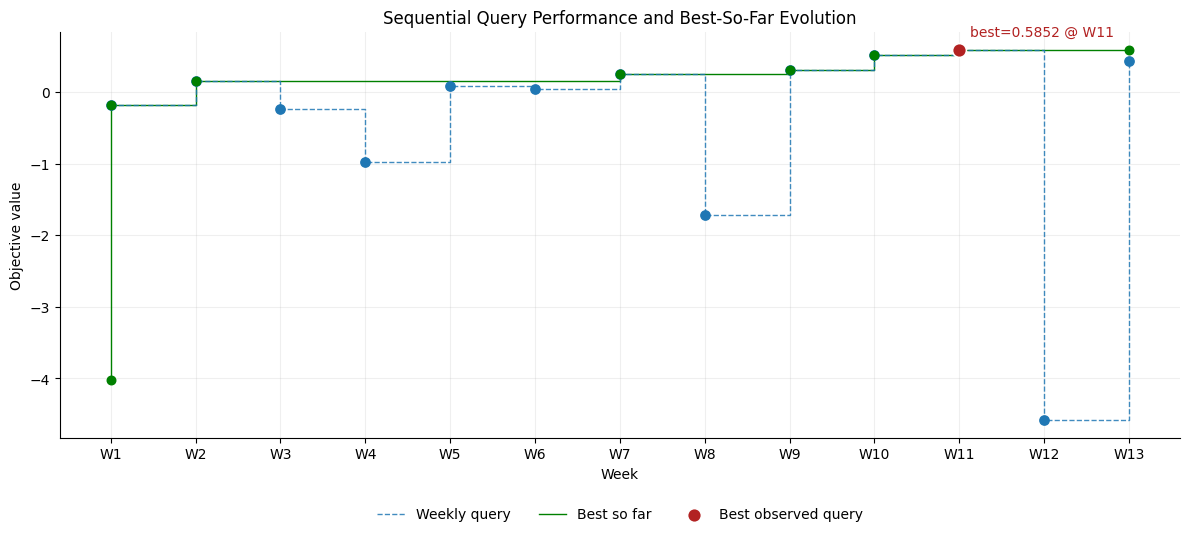

In [8]:
performance, performance_summary = sequential_performance(
    initial_outputs=outputs[:INITIAL_OBSERVATIONS],
    query_outputs=query_outputs)

display(performance_summary)
display(performance)

plot_sequential_query_performance(
    performance,
    FUNCTION_ID,
    yscale="linear",
    plot_type="bar")

**Performance result.** The incumbent moves from approximately **$-4.025542$** to **$0.585186$**, an absolute gain of about **4.610728**.

**6 of the 13** sequential queries improve the incumbent directly: **Weeks 1, 2, 7, 9, 10 and 11**. The search therefore has two distinct improvement episodes: the first two global UCB queries identify the promising region quickly, while the later EI-led phase delivers four further refinements before the final local query confirms a strong neighbourhood without beating the incumbent.

**5.2 - Surrogate robustness**

The historical experiment primarily used a fitted RBF GP, while the final local stage used Matérn-5/2. The comparison below evaluates both specifications retrospectively on the complete observed dataset.

- **LOOCV RMSE:** lower is better.
- **Spearman rank correlation:** higher means better preservation of the ordering of relatively strong and weak observations.

This is a retrospective diagnostic; it does not imply that the kernel with the best full-sample validation score should necessarily have been chosen at Week 1.

In [9]:
predictive_kernels = {
    "RBF_fitted": (RBF(length_scale=0.2)+ WhiteKernel(noise_level=1e-6)),
    "Matern_52": (ConstantKernel(1.0, (1e-3, 1e3))* Matern(length_scale=np.full(DIMENSION, 0.20),
                                                           length_scale_bounds=(1e-2, 3.0),
                                                           nu=2.5)
                + WhiteKernel(noise_level=1e-6,noise_level_bounds=(1e-8, 1e-2)))}

surrogate_robustness = kernel_choice_validation(
    inputs,
    outputs,
    predictive_kernels,
    alpha=1e-10,
    normalize_y=True,
    n_restarts_optimizer=3,
    random_state=RANDOM_SEED)

display(surrogate_robustness)

,kernel,LOOCV_RMSE,Spearman_rank_correlation
0,RBF_fitted,1.965952,0.970100
1,Matern_52,1.146407,0.984144


**Interpretation.** Matérn-5/2 provides the stronger retrospective fit among these two historical surrogate families, with lower held-out error and slightly better rank preservation on the accumulated observations.

The fitted RBF nevertheless preserves the broad ordering of the data well. The main conclusion is therefore not that the early RBF was invalid, but that the later Matérn specification provides a credible robustness check once substantially more data have been collected.

**5.3 - UCB versus EI acquisition diagnostic**

Across Weeks 1–12, UCB and EI are compared on the same complete historical Cartesian grid used for each week.

During Weeks 1–5, UCB remains the selected acquisition and EI is evaluated retrospectively. From Week 6, EI becomes the selected acquisition and evolving-$\kappa$ UCB is retained as the diagnostic.

The distance between their proposed candidates indicates whether the two acquisition rules favour similar regions. Because both are evaluated on the same candidate grid, differences reflect the acquisition rule rather than candidate generation.

The historically selected acquisition is checked against `historical_record()` to verify reproduction of the optimisation path.

In [10]:
phase_1_diagnostic = phase_1_history[
    [   "week",
        "grid_resolution",
        "selected_acquisition",
        "kappa",
        "EI_candidate",
        "UCB_candidate",
        "EI_UCB_candidate_distance",
        "selected_matches_record"]]

phase_2_diagnostic = phase_2_history[
    [   "week",
        "grid_resolution",
        "selected_acquisition",
        "kappa",
        "EI_candidate",
        "UCB_candidate",
        "EI_UCB_candidate_distance",
        "selected_matches_record"]]

acquisition_diagnostic = pd.concat([phase_1_diagnostic, phase_2_diagnostic], ignore_index=True)

display(acquisition_diagnostic.style.set_properties(
        subset=["UCB_candidate", "EI_candidate"],
        **{"white-space": "nowrap"}))

diagnostic_summary = pd.DataFrame({
    "metric": [
        "Weeks compared",
        "Median EI-UCB candidate distance",
        "Historical selected queries reproduced"],
    "value": [
        len(acquisition_diagnostic),
        acquisition_diagnostic["EI_UCB_candidate_distance"].median(),
        int(acquisition_diagnostic["selected_matches_record"].sum())]})

display(diagnostic_summary)

,week,grid_resolution,selected_acquisition,kappa,EI_candidate,UCB_candidate,EI_UCB_candidate_distance,selected_matches_record
0,1,50,UCB,1.500000,"[0.44898, 0.44898, 0.387755, 0.428571]","[0.428571, 0.44898, 0.367347, 0.44898]",0.035348,True
1,2,50,UCB,1.500000,"[0.408163, 0.44898, 0.408163, 0.428571]","[0.408163, 0.44898, 0.428571, 0.428571]",0.020408,True
2,3,50,UCB,2.500000,"[0.408163, 0.44898, 0.428571, 0.428571]","[0.408163, 0.408163, 0.44898, 0.44898]",0.049990,True
3,4,50,UCB,3.000000,"[0.408163, 0.469388, 0.428571, 0.428571]","[0.408163, 0.489796, 0.428571, 0.408163]",0.028862,True
4,5,50,UCB,0.894000,"[0.428571, 0.428571, 0.367347, 0.44898]","[0.428571, 0.428571, 0.387755, 0.44898]",0.020408,True
5,6,50,EI,0.816000,"[0.428571, 0.408163, 0.387755, 0.44898]","[0.428571, 0.428571, 0.387755, 0.44898]",0.020408,True
6,7,75,EI,0.756000,"[0.418919, 0.418919, 0.378378, 0.445946]","[0.418919, 0.418919, 0.378378, 0.445946]",0.000000,True
7,8,75,EI,0.707000,"[0.243243, 0.418919, 0.378378, 0.418919]","[0.216216, 0.418919, 0.378378, 0.432432]",0.030217,True
8,9,75,EI,0.667000,"[0.378378, 0.378378, 0.391892, 0.351351]","[0.378378, 0.364865, 0.391892, 0.324324]",0.030217,True
9,10,75,EI,0.632000,"[0.378378, 0.418919, 0.391892, 0.418919]","[0.364865, 0.418919, 0.391892, 0.418919]",0.013514,True


,metric,value
0,Weeks compared,12.000000
1,Median EI-UCB candidate distance,0.020408
2,Historical selected queries reproduced,12.000000


**Interpretation:** This diagnostic checks acquisition robustness across Weeks 1–12 rather than comparing raw EI and UCB magnitudes. Because both acquisitions are evaluated on the same historical candidate grid each week, differences between their proposed locations reflect the acquisition rule itself.

The reproducibility flag checks whether the historically selected acquisition reproduces the query stored in `historical_record()`: UCB in Weeks 1–5 and EI in Weeks 6–12. The non-selected acquisition is used only as a diagnostic.

**5.4 - Early RBF decision sensitivity**

The early RBF length scale was **optimised**, not fixed. The first check therefore asks whether reasonable starting values converge to materially different fitted models. The following checks then isolate the two main acquisition-design choices: UCB $\kappa$ and Cartesian resolution.

**5.4.1 - RBF initialisation sensitivity**

In [11]:
rbf_initialisation_rows = []

for initial_scale in [0.05, 0.10, 0.20, 0.40]:
    gp = GaussianProcessRegressor(
        kernel=build_kernel("rbf", length_scale=initial_scale, length_scale_bounds=(1e-5, 1e5),noise_level=1e-6),
        alpha=1e-10,
        normalize_y=True,
        n_restarts_optimizer=0,
        random_state=RANDOM_SEED)
    
    gp.fit(inputs[:INITIAL_OBSERVATIONS],outputs[:INITIAL_OBSERVATIONS])

    rbf_initialisation_rows.append({
        "initial_length_scale": initial_scale,
        "fitted_length_scale": float(gp.kernel_.k1.length_scale),
        "fitted_noise_level": float(gp.kernel_.k2.noise_level),
        "log_marginal_likelihood": gp.log_marginal_likelihood_value_})

rbf_initialisation_sensitivity = pd.DataFrame(rbf_initialisation_rows)
display(rbf_initialisation_sensitivity)

,initial_length_scale,fitted_length_scale,fitted_noise_level,log_marginal_likelihood
0,0.05,0.50023,0.00001,-24.031713
1,0.10,0.50023,0.00001,-24.031713
2,0.20,0.50023,0.00001,-24.031713
3,0.40,0.50023,0.00001,-24.031713


**Interpretation.** The tested starting values converge to the same fitted RBF length scale (approximately **0.50**) and the same log-marginal likelihood. The historical initial value $0.20$ therefore does not appear to be a fragile optimiser starting point for the initial 30 observations.

**5.4.2 - UCB $\kappa$ sensitivity**

The historical Week 1 decision used $\kappa=1.5$. The test below scans the same exact $50^4$ grid in chunks and records the maximiser for nearby exploration weights.

In [12]:
# Reconstruct the Week 1 GP from the initial observations
week_1_gp = GaussianProcessRegressor(
    kernel=build_kernel(
        "rbf",
        length_scale=0.2,
        length_scale_bounds=(1e-5, 1e5),
        noise_level=1e-6),
    alpha=1e-10,
    normalize_y=True)

week_1_gp.fit(initial_inputs, initial_outputs)

kappa_values = [1.0, 1.5, 2.0, 2.50, 3.0, 4.0]

kappa_results = exhaustive_kappa_sensitivity_4d(
    week_1_gp,
    resolution=50,
    kappas=kappa_values)

reference_candidate = kappa_results[1.5]["candidate"]

kappa_sensitivity = pd.DataFrame([
    {   "kappa": kappa,
        "candidate_x1": result["candidate"][0],
        "candidate_x2": result["candidate"][1],
        "candidate_x3": result["candidate"][2],
        "candidate_x4": result["candidate"][3],
        "distance_from_kappa_1.5": np.linalg.norm(result["candidate"] - reference_candidate),
        "acquisition_max": result["score"]}
    for kappa, result in kappa_results.items()])

display(kappa_sensitivity)

,kappa,candidate_x1,candidate_x2,candidate_x3,candidate_x4,distance_from_kappa_1.5,acquisition_max
0,1.0,0.428571,0.44898,0.387755,0.428571,0.028862,0.051020
1,1.5,0.428571,0.44898,0.367347,0.448980,0.000000,0.490473
2,2.0,0.408163,0.44898,0.367347,0.448980,0.020408,0.943321
3,2.5,0.408163,0.44898,0.367347,0.448980,0.020408,1.414072
4,3.0,0.408163,0.44898,0.367347,0.448980,0.020408,1.884823
5,4.0,0.408163,0.44898,0.306122,0.448980,0.064536,2.872160


**Interpretation.** Reasonable changes in $\kappa$ move the numerical maximiser only gradually within the same broad region around $x_1\approx0.41$–$0.43$, $x_2\approx0.45$, $x_3\approx0.37$–$0.39$ and $x_4\approx0.43$–$0.45$.

The historical $\kappa=1.5$ therefore does not act as a fragile threshold determining a completely different Week 1 direction.

**5.4.3 - Four-dimensional Cartesian-grid sensitivity**

In four dimensions, resolution is not a cosmetic choice: the candidate count grows as $r^4$. The same Week 1 GP and $\kappa=1.5$ are therefore evaluated on increasingly fine grids using the chunked search helper.

In [13]:
# Historical Week 1 reference on the 50^4 grid
reference_search = exhaustive_cartesian_search_4d(
    week_1_gp,
    resolution=50,
    kappa=1.5,
    compute_ucb=True)

reference_candidate = reference_search["ucb_point"]

grid_rows = []

for resolution in [15, 25, 35, 50]:
    search_result = exhaustive_cartesian_search_4d(
        week_1_gp,
        resolution=resolution,
        kappa=1.5,
        compute_ucb=True)

    candidate = search_result["ucb_point"]

    grid_rows.append({
        "resolution": resolution,
        "n_candidates": search_result["n_candidates"],
        "candidate_x1": candidate[0],
        "candidate_x2": candidate[1],
        "candidate_x3": candidate[2],
        "candidate_x4": candidate[3],
        "distance_from_50_grid": np.linalg.norm(
            candidate - reference_candidate),
        "acquisition_max": search_result["ucb_max"]})

grid_sensitivity = pd.DataFrame(grid_rows)
display(grid_sensitivity)

,resolution,n_candidates,candidate_x1,candidate_x2,candidate_x3,candidate_x4,distance_from_50_grid,acquisition_max
0,15,50625,0.428571,0.428571,0.357143,0.428571,0.030612,0.426774
1,25,390625,0.416667,0.458333,0.375000,0.458333,0.019372,0.471293
2,35,1500625,0.411765,0.441176,0.382353,0.441176,0.025088,0.482572
3,50,6250000,0.428571,0.448980,0.367347,0.448980,0.000000,0.490473


**Interpretation.** Finer grids refine the precise coordinate but keep the recommendation in the same compact part of the domain. The historical $50^4$ grid is therefore regionally stable for the Week 1 decision.

The more important lesson is computational: moving from $50^4$ to $75^4$ multiplies the candidate count by more than five. That scaling cost is one reason the final phase benefits from a local low-discrepancy candidate design rather than another exhaustive tensor grid.

**5.5 - Local Matérn decision stability**

The final local decision introduced two researcher-controlled choices:

- the initial Matérn ARD length scale;
- the local search radius.

Both are tested at the state immediately before Week 13, holding the Sobol seed, EI rule and observed data fixed.

In [14]:
# Recreate the historical Week 13 candidate pool at radius 0.12
historical_lower, historical_upper = search_region(incumbent_x, LOCAL_RADIUS)
historical_sampler = qmc.Sobol(d=DIMENSION, scramble=True, seed=SOBOL_SEED)
historical_candidates = historical_sampler.random_base2(SOBOL_POWER)
historical_candidates = (historical_lower + (historical_upper - historical_lower) * historical_candidates)
historical_candidates = filter_candidates(historical_candidates, pre_week_13_inputs, min_distance=MIN_DISTANCE)

matern_initialisation_rows = []

for initial_scale in [0.05, 0.10, 0.20, 0.40]:
    gp = GaussianProcessRegressor(
        kernel=matern_52_kernel(initial_scale),
        normalize_y=True,
        n_restarts_optimizer=12,
        random_state=RANDOM_SEED)
    
    gp.fit(pre_week_13_inputs, pre_week_13_outputs)

    mean, std = gp.predict(historical_candidates, return_std=True)
    scores = expected_improvement(mean, std, best=incumbent_y, xi=XI)
    candidate = historical_candidates[np.argmax(scores)]

    fitted_scales = np.atleast_1d(gp.kernel_.k1.k2.length_scale)

    matern_initialisation_rows.append({
        "initial_scale": initial_scale,
        "fitted_scale_x1": fitted_scales[0],
        "fitted_scale_x2": fitted_scales[1],
        "fitted_scale_x3": fitted_scales[2],
        "fitted_scale_x4": fitted_scales[3],
        "candidate_x1": candidate[0],
        "candidate_x2": candidate[1],
        "candidate_x3": candidate[2],
        "candidate_x4": candidate[3],
        "distance_to_historical_week_13": np.linalg.norm(candidate - recorded_week_13),
        "log_marginal_likelihood": gp.log_marginal_likelihood_value_})

matern_initialisation_sensitivity = pd.DataFrame(matern_initialisation_rows)

display(matern_initialisation_sensitivity)

,initial_scale,fitted_scale_x1,fitted_scale_x2,fitted_scale_x3,fitted_scale_x4,candidate_x1,candidate_x2,candidate_x3,candidate_x4,distance_to_historical_week_13,log_marginal_likelihood
0,0.05,1.62365,1.665802,1.588047,1.625357,0.395818,0.366669,0.386164,0.418456,4.505846e-07,6.869527
1,0.10,1.62365,1.665802,1.588047,1.625357,0.395818,0.366669,0.386164,0.418456,4.505846e-07,6.869527
2,0.20,1.62365,1.665802,1.588047,1.625357,0.395818,0.366669,0.386164,0.418456,4.505846e-07,6.869527
3,0.40,1.62365,1.665802,1.588047,1.625357,0.395818,0.366669,0.386164,0.418456,4.505846e-07,6.869527


In [15]:
# Radius sensitivity using the historical fitted local GP
radius_rows = []

for radius_value in [0.06, 0.08, 0.12, 0.16, 0.20]:
    radius = np.full(DIMENSION, radius_value)
    lower, upper = search_region(incumbent_x, radius)

    sampler = qmc.Sobol(d=DIMENSION, scramble=True, seed=SOBOL_SEED)
    candidates = sampler.random_base2(SOBOL_POWER)
    candidates = lower + (upper - lower) * candidates
    candidates = filter_candidates(candidates, pre_week_13_inputs, min_distance=MIN_DISTANCE)

    mean, std = local_gp.predict(candidates, return_std=True)
    scores = expected_improvement(mean, std, best=incumbent_y, xi=XI)
    candidate = candidates[np.argmax(scores)]

    radius_rows.append({
        "radius_per_dimension": radius_value,
        "n_candidates_after_filter": len(candidates),
        "candidate_x1": candidate[0],
        "candidate_x2": candidate[1],
        "candidate_x3": candidate[2],
        "candidate_x4": candidate[3],
        "distance_to_incumbent": np.linalg.norm(candidate - incumbent_x),
        "EI_max": float(np.max(scores))})

radius_sensitivity = pd.DataFrame(radius_rows)
display(radius_sensitivity)

,radius_per_dimension,n_candidates_after_filter,candidate_x1,candidate_x2,candidate_x3,candidate_x4,distance_to_incumbent,EI_max
0,0.06,10064,0.401899,0.373849,0.395026,0.408084,0.052801,0.054060
1,0.08,13292,0.411851,0.362435,0.385133,0.417122,0.050413,0.053317
2,0.12,15488,0.395818,0.366669,0.386164,0.418456,0.051799,0.054488
3,0.16,16082,0.388118,0.353757,0.393264,0.413798,0.069065,0.046119
4,0.20,16224,0.402457,0.364109,0.390582,0.431916,0.051361,0.049436


**Decision-stability conclusion.** The tested Matérn starting values converge to essentially the same fitted local model and reproduce the same Week 13 recommendation. Changing the local radius moves the precise Sobol maximiser, but the candidates remain concentrated around the incumbent rather than relocating to a qualitatively different part of the domain.

The final local decision is therefore not materially explained by one arbitrary Matérn starting value or one exact radius choice.

<h1 style="color:#0000CD;font-size:19px;">6. Conclusion and limitations</h1>

Function 4 improves the initial incumbent from approximately **$-4.025542$** to **$0.585186$** over 13 sequential evaluations, with improvements in Weeks **1, 2, 7, 9, 10 and 11**.

The search follows three stages:

- **Global RBF-UCB (Weeks 1–5):** rapidly identifies a stronger region and delivers the first two improvements. EI is evaluated retrospectively, while UCB remains the selected acquisition.
- **Global RBF-EI (Weeks 6–12):** shifts the search toward expected improvement, with evolving-$\kappa$ UCB retained as a diagnostic on the same exhaustive historical grid.
- **Local Matérn-5/2 EI (Week 13):** after the poor Week 12 result, applies the original scrambled Sobol local search around the incumbent. The final query is strong but does not improve the Week 11 best.

The historical search design is preserved: the exact $50^4$ and $75^4$ Cartesian grids are scanned in the original `meshgrid` order, with slabbed evaluation used to control memory. Each historically selected query is checked against `historical_record()`, the single source of truth for the experiment path.

Retrospective diagnostics test the main researcher-controlled choices: surrogate family, RBF initialisation, UCB exploration weight, grid resolution, EI-UCB agreement, and the final local Matérn initialisation and radius.

In four dimensions, tensor-grid cost grows as $r^4$, making exact $75^4$ reproduction expensive; slabbed evaluation avoids storing all 31.6 million candidates in memory at once.

**Limitations.** The notebook identifies the **best observed configuration under the available query budget**, not the global maximum, and provides no controlled counterfactual showing that the historical acquisition sequence outperformed an alternative Bayesian-optimisation policy.